1. Loading Data...
2. Preprocessing Data...
3. Training Random Forest Model...

--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       277
           1       0.76      0.67      0.72        43

    accuracy                           0.93       320
   macro avg       0.86      0.82      0.84       320
weighted avg       0.93      0.93      0.93       320

ROC-AUC Score: 0.9359

4. Generating SHAP Explainability Plot...


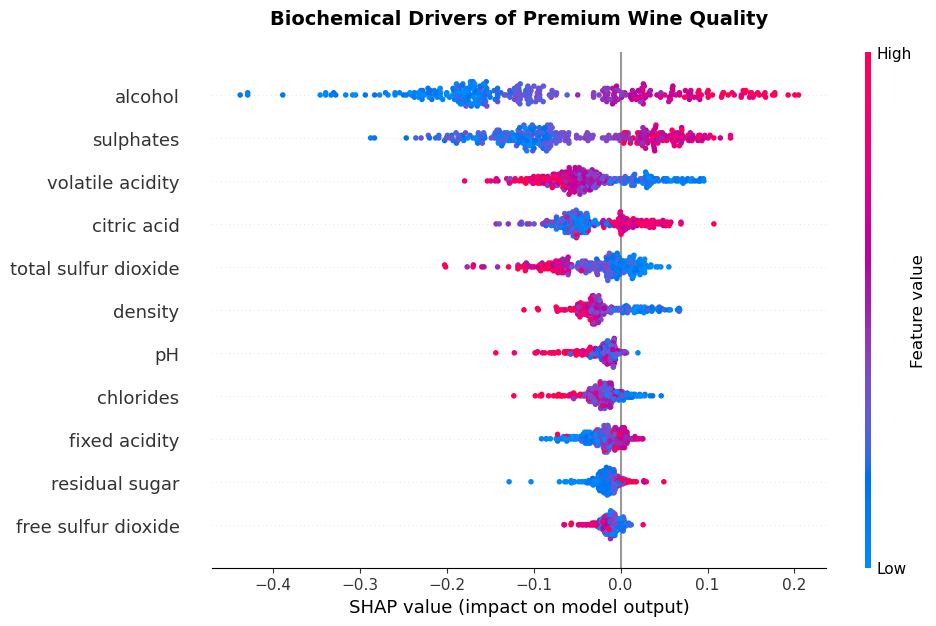

In [1]:

# PREMIUM WINE CLASSIFIER - COMPLETE PIPELINE
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Bypass security block for data download
ssl._create_default_https_context = ssl._create_unverified_context
%matplotlib inline

print("1. Loading Data...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

print("2. Preprocessing Data...")
wine_data['is_premium'] = (wine_data['quality'] >= 7).astype(int)
X = wine_data.drop(['quality', 'is_premium'], axis=1)
y = wine_data['is_premium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("3. Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("4. Generating SHAP Explainability Plot...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Handle SHAP formatting
shap_values_premium = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# Render Plot
plt.clf()
shap.summary_plot(shap_values_premium, X_test_scaled, show=False, plot_size=(10, 6))
plt.title("Biochemical Drivers of Premium Wine Quality", fontsize=14, fontweight='bold', pad=20)
plt.show()